In [3]:
import os
import zipfile
import kagglehub
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
base_path = kagglehub.competition_download('dogs-vs-cats')
print(f"Downloaded zip file at: {base_path}")

train_zip=os.path.join(base_path,'train.zip')
test_zip=os.path.join(base_path,'test1.zip')

print("Unzipping...")

os.makedirs('data', exist_ok=True)

with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall('data')

with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall('data')

print("Success?")

100%|██████████| 812M/812M [00:12<00:00, 70.4MB/s]

Extracting files...


Downloaded zip file at: /root/.cache/kagglehub/competitions/dogs-vs-cats
Unzipping...
Success?


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [5]:
from torchvision import datasets,models,transforms
from torch.utils.data import DataLoader, Dataset,ConcatDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import torchvision
import copy
import tqdm
from PIL import Image
import zipfile

In [6]:
lr =0.001
batch_size=100
epochs = 10


In [7]:
device="cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(1234)
if device == 'cuda':
    torch.cuda.manual_seed_all(1234)

In [8]:
# Load train and test data
train_dir = 'data/train'
test_dir = 'data/test1'
import glob

train_list = glob.glob(os.path.join(train_dir,'*.jpg'))
test_list = glob.glob(os.path.join(test_dir, '*.jpg'))

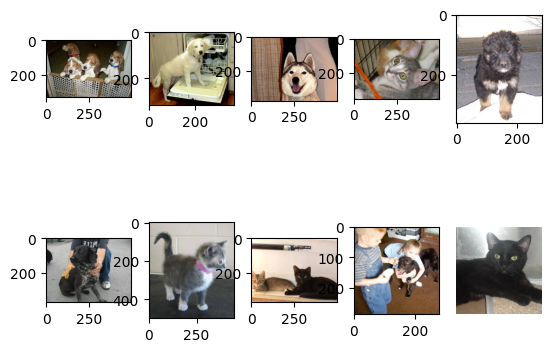

In [9]:
random_idx = np.random.randint(1,25000,size=10)

fig = plt.figure()
i=1
for idx in random_idx:
    ax = fig.add_subplot(2,5,i)
    img = Image.open(train_list[idx])
    plt.imshow(img)
    i+=1

plt.axis('off')
plt.show()

In [10]:
train_list[0].split('/')[-1].split('.')[0]

'dog'

In [11]:
train_transforms =transforms.Compose([
    transforms.Resize((256,256)), # zoom a bit first
    transforms.RandomResizedCrop(224), # then crop randomly to 224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])


# remember to remove the crop & flip part, only use challenges to train, test data must be original
val_transforms  =transforms.Compose([
    transforms.Resize((224,224)),
    #transforms.RandomResizedCrop(224),
    #transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])


# same as the above
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    #transforms.RandomResizedCrop(224),
    #transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])




In [12]:
class dataset(torch.utils.data.Dataset):
    def __init__(self,file_list,transform = None):
        self.file_list=file_list
        self.transform=transform

    def __len__(self):
        self.filelength =len(self.file_list)
        return self.filelength

    def __getitem__(self,idx):
        img_path =self.file_list[idx]
        img = Image.open(img_path)
        if self.transform is not None:
            img_transformed = self.transform(img)
        else:
            img_transformed = img

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label=1
        elif label == 'cat':
            label=0

        return img_transformed,label


In [13]:
from sklearn.model_selection import train_test_split
train_list,val_list = train_test_split(train_list , test_size =0.2)

In [14]:
train_data = dataset(train_list,transform=train_transforms)
test_data = dataset(test_list,transform=test_transforms)
val_data = dataset(val_list,transform=val_transforms)



In [15]:
train_loader = torch.utils.data.DataLoader(dataset = train_data, batch_size = batch_size,shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset = test_data, batch_size = batch_size,shuffle = True)
val_loader = torch.utils.data.DataLoader(dataset = val_data, batch_size = batch_size,shuffle = True)

In [16]:
print(len(train_data),len(train_loader))
print(len(val_data), len(val_loader))


20000 200
5000 50


In [17]:
train_data[0][0].shape

torch.Size([3, 224, 224])

In [18]:
class Cnn(nn.Module):
    def __init__(self):
        super(Cnn,self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3,16,kernel_size=3,padding=0,stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(16,32,kernel_size=3,padding=0,stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )


        self.layer3 = nn.Sequential(
            nn.Conv2d(32,64,kernel_size=3,padding=0,stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = nn.Linear(3*3*64,10)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(10,2)
        self.relu = nn.ReLU()

    def forward(self,x):
        out =self.layer1(x)
        out =self.layer2(out)
        out =self.layer3(out)
        out =out.view(out.size(0),-1)  #flatten
        out =self.relu(self.fc1(out))
        out =self.fc2(out)
        return out



In [19]:
model = Cnn().to(device)
model.train()
optimizer = optim.Adam(params = model.parameters(),lr =0.001)
criterion = nn.CrossEntropyLoss()

In [20]:
epochs = 10

for epoch in range(epochs):
    epoch_loss =0
    epoch_accuracy = 0

    for data,label in train_loader:
        data= data.to(device)
        label = label.to(device)

        output = model(data)
        loss = criterion(output,label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = ((output.argmax(dim=1)==label).float().mean())
        epoch_accuracy += acc/len(train_loader)
        epoch_loss += loss/len(train_loader)

    print('Epoch : {}, train accuracy : {}, train loss : {}'.format(epoch+1, epoch_accuracy,epoch_loss))

    model.eval()

    with torch.no_grad():
        epoch_val_accuracy =0
        epoch_val_loss = 0
        for data,label in  val_loader:
            data= data.to(device)
            label = label.to(device)

            val_output = model(data)
            val_loss = criterion(val_output,label)


            acc = ((val_output.argmax(dim=1)==label).float().mean())
            epoch_val_accuracy += acc/len(val_loader)
            epoch_val_loss += val_loss/len(val_loader)
        print('Epoch : {}, val_accuracy : {}, val_loss : {}'.format(epoch+1, epoch_val_accuracy,epoch_val_loss))
    model.train()

Epoch : 1, train accuracy : 0.6426000595092773, train loss : 0.6284138560295105
Epoch : 1, val_accuracy : 0.7215999960899353, val_loss : 0.5578102469444275
Epoch : 2, train accuracy : 0.7008501887321472, train loss : 0.5670153498649597
Epoch : 2, val_accuracy : 0.6952000260353088, val_loss : 0.605463981628418
Epoch : 3, train accuracy : 0.7239501476287842, train loss : 0.5367066860198975
Epoch : 3, val_accuracy : 0.7348000407218933, val_loss : 0.5337353348731995
Epoch : 4, train accuracy : 0.7393999099731445, train loss : 0.5198856592178345
Epoch : 4, val_accuracy : 0.7719998955726624, val_loss : 0.4745768904685974
Epoch : 5, train accuracy : 0.7521502375602722, train loss : 0.4955107867717743
Epoch : 5, val_accuracy : 0.7173999547958374, val_loss : 0.6044044494628906
Epoch : 6, train accuracy : 0.7544500231742859, train loss : 0.49256038665771484
Epoch : 6, val_accuracy : 0.7841998338699341, val_loss : 0.45397669076919556
Epoch : 7, train accuracy : 0.7664999961853027, train loss : 0.

In [21]:
dog_probs = []
model.eval()
with torch.no_grad():
    for data, fileid in test_loader:
        data = data.to(device)
        preds = model(data)
        preds_list = F.softmax(preds, dim=1)[:, 1].tolist()
        dog_probs += list(zip(list(fileid), preds_list))

In [22]:
dog_probs.sort(key = lambda x: int(x[0]))
dog_probs

[('1', 0.8379672765731812),
 ('2', 0.8737109303474426),
 ('3', 0.552043080329895),
 ('4', 0.9900160431861877),
 ('5', 0.07532114535570145),
 ('6', 0.630362868309021),
 ('7', 0.014015396125614643),
 ('8', 0.3346681594848633),
 ('9', 0.10595604032278061),
 ('10', 0.12168431282043457),
 ('11', 0.013765566982328892),
 ('12', 0.9150482416152954),
 ('13', 0.1965511590242386),
 ('14', 0.5785306096076965),
 ('15', 0.060361575335264206),
 ('16', 0.028742510825395584),
 ('17', 0.9073183536529541),
 ('18', 0.9741515517234802),
 ('19', 0.1359318643808365),
 ('20', 0.4714066982269287),
 ('21', 0.8050558567047119),
 ('22', 0.2192714810371399),
 ('23', 0.5788531303405762),
 ('24', 0.930927038192749),
 ('25', 0.3943042457103729),
 ('26', 0.652249813079834),
 ('27', 0.7221097946166992),
 ('28', 0.0325162373483181),
 ('29', 0.8807929754257202),
 ('30', 0.8056988716125488),
 ('31', 0.8873870968818665),
 ('32', 0.04555272310972214),
 ('33', 0.9636749029159546),
 ('34', 0.2145494818687439),
 ('35', 0.01067

In [23]:
idx = list(map(lambda x :x[0],dog_probs))
prob = list(map(lambda x :x[1],dog_probs))

In [24]:
submission = pd.DataFrame({'id':idx, 'label':prob})


In [25]:
submission


,id,label
0,1,0.837967
1,2,0.873711
2,3,0.552043
3,4,0.990016
4,5,0.075321
...,...,...
12495,12496,0.188655
12496,12497,0.223610
12497,12498,0.511226
12498,12499,0.938320


In [ ]:
submission.to_csv('result.csv',index=False)


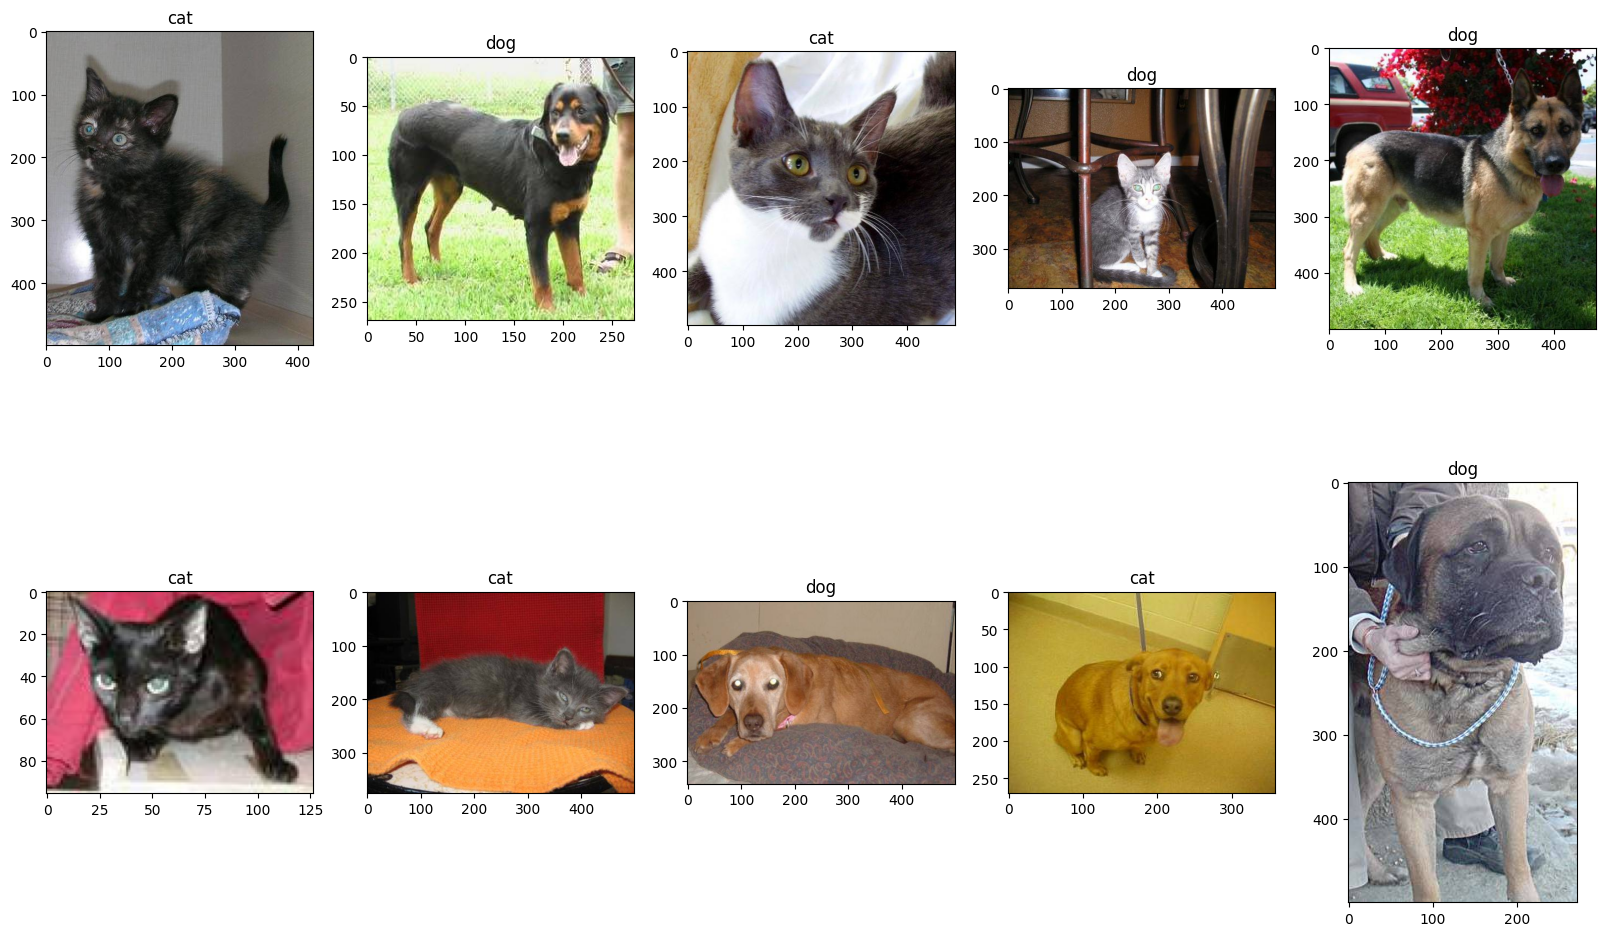

In [28]:
import random

id_list = []
class_ = {0: 'cat', 1: 'dog'}

fig, axes = plt.subplots(2, 5, figsize=(20, 12), facecolor='w')

for ax in axes.ravel():

    i = random.choice(submission['id'].values)

    label = submission.loc[submission['id'] == i, 'label'].values[0]
    if label > 0.5:
        label = 1
    else:
        label = 0

    img_path = os.path.join(test_dir, '{}.jpg'.format(i))
    img = Image.open(img_path)

    ax.set_title(class_[label])
    ax.imshow(img)

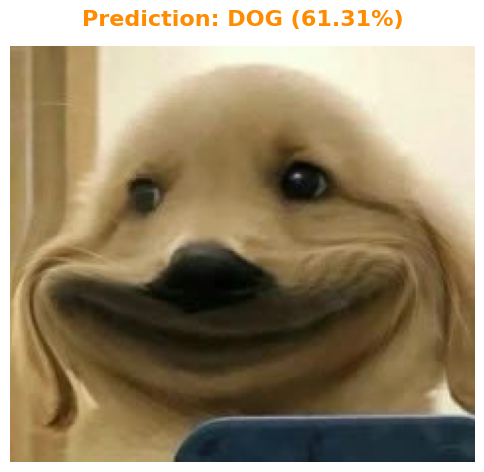

In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

def predict_and_show_image(image_path, model, device):
    # 1. Khởi động mode đi thi
    model.eval()

    # 2. Định nghĩa băng chuyền xử lý
    custom_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # 3. Mở ảnh GỐC (giữ lại biến này để lát vẽ)
    img_original = Image.open(image_path).convert('RGB')

    # 4. Ép kiểu sang Tensor và thêm chiều Batch
    img_tensor = custom_transform(img_original).unsqueeze(0).to(device)

    # 5. Đưa cho Model phán xét
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = F.softmax(output, dim=1)[0]

        cat_prob = probabilities[0].item() * 100
        dog_prob = probabilities[1].item() * 100

    # --- CHỐT KẾT QUẢ ---
    if dog_prob > cat_prob:
        final_label = "DOG"
        confidence = dog_prob
    else:
        final_label = "CAT"
        confidence = cat_prob

    # Tạo một khung tranh vuông vắn
    plt.figure(figsize=(6, 6))

    # Vẽ bức ảnh GỐC lên khung tranh
    plt.imshow(img_original)

    # Tự tin > 80% chữ màu xanh, lấp lửng thì chữ màu cam
    title_color = 'green' if confidence > 80.0 else 'darkorange'

    # Gắn tiêu đề
    plt.title(f"Prediction: {final_label} ({confidence:.2f}%)",
              fontsize=16,
              fontweight='bold',
              color=title_color,
              pad=15) # pad để tạo khoảng cách giữa chữ và ảnh


    plt.axis('off')


    plt.show()
predict_and_show_image("thong.jpg", model, device)



In [36]:
from google.colab import drive
import json

# 1. Mount Google Drive của bạn vào Colab để làm nơi lưu trữ vĩnh viễn
drive.mount('/content/drive')

# 2. Tạo một thư mục riêng cho project nhóm
import os
save_path = '/content/drive/MyDrive/DogCat_Project'
os.makedirs(save_path, exist_ok=True)

# 3. LƯU "TRÍ NHỚ" (Trọng số của mô hình)
model_file = os.path.join(save_path, 'cnn_model_v1.pth')
# state_dict() là cuốn từ điển chứa toàn bộ các con số trọng số mà AI vừa học được
torch.save(model.state_dict(), model_file)
print(f"Đã lưu não bộ AI tại: {model_file}")

# 4. LƯU SIÊU THAM SỐ (Cách làm cực kỳ chuyên nghiệp)
# Lưu lại cấu hình để sau này các thành viên trong nhóm biết model này được train thế nào
hyperparams = {
    "learning_rate": 0.001,
    "batch_size": 100,
    "epochs": 10,
    "optimizer": "Adam",
    "accuracy": epoch_val_accuracy.item() # Điểm số lúc test
}
with open(os.path.join(save_path, 'config_v1.json'), 'w') as f:
    json.dump(hyperparams, f, indent=4)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã lưu não bộ AI tại: /content/drive/MyDrive/DogCat_Project/cnn_model_v1.pth
